# Lab 5 Report:
## Stock Prediction AI with Encoder-Decoder RNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns

In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

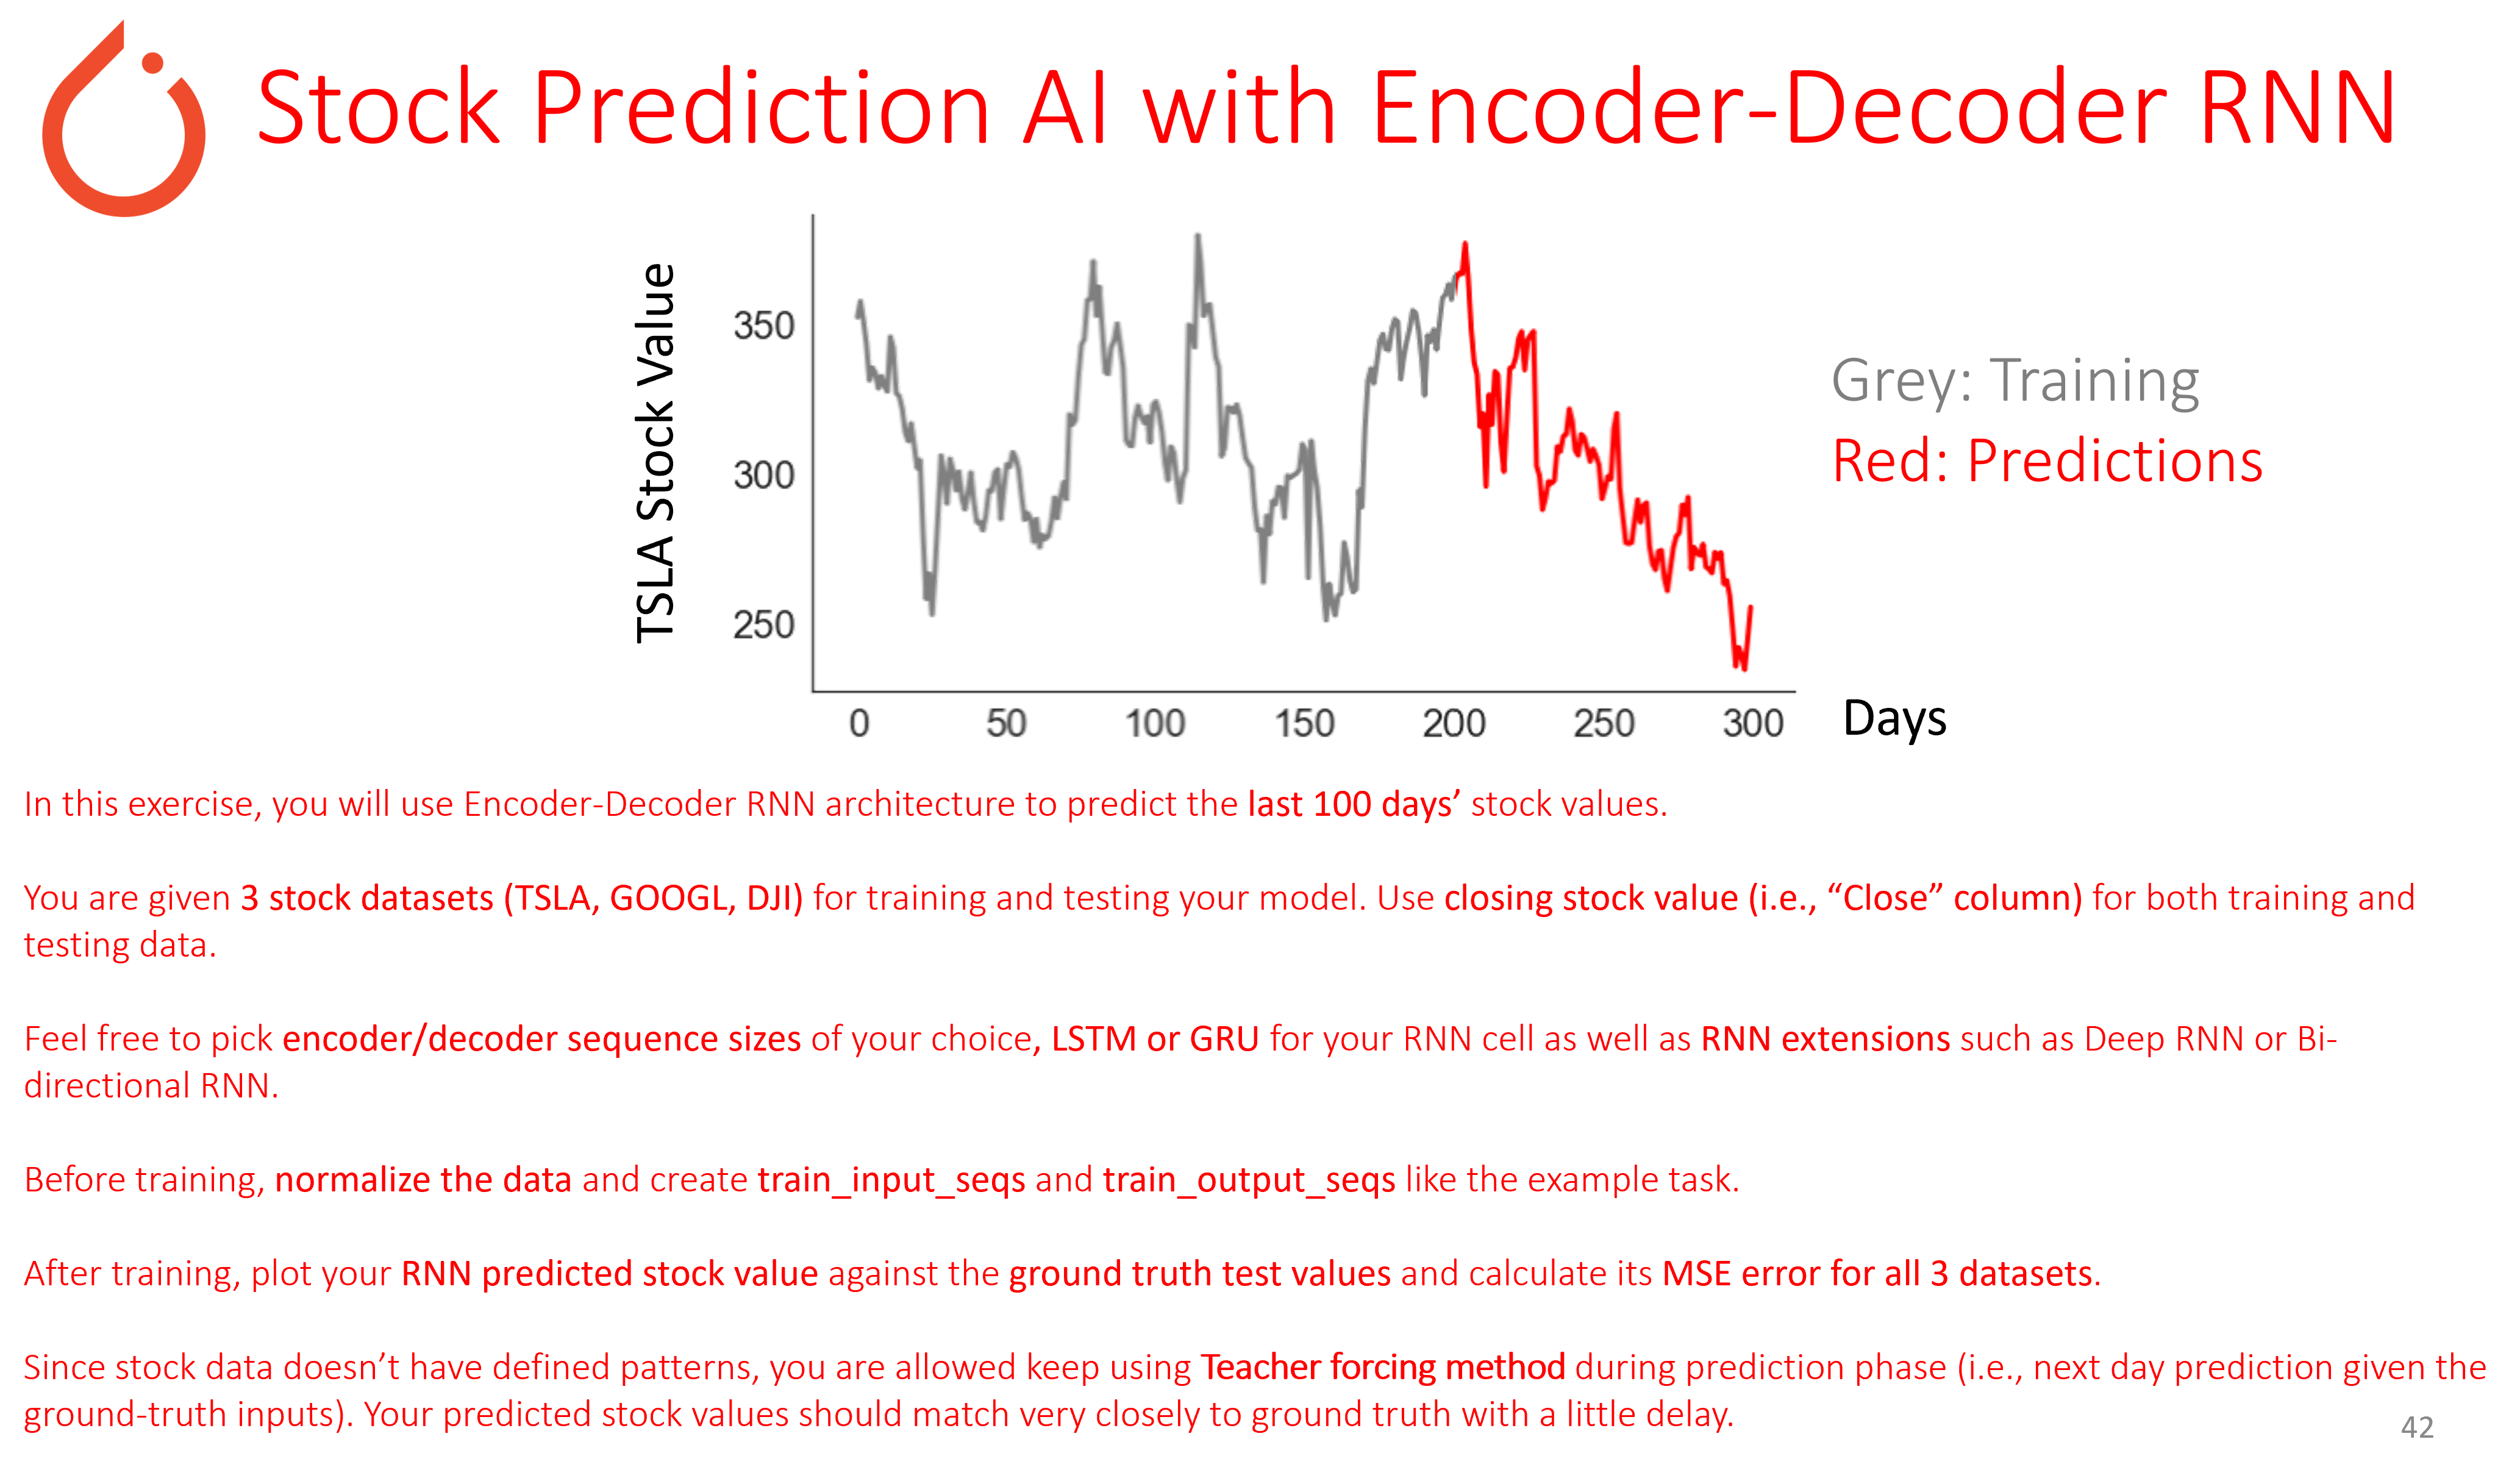

In [3]:
Image('lab5_exercise.png', width = 1000)

In [4]:
# Seaborn plot styling
sns.set(style = 'white', font_scale = 2)

## Prepare Data

In [5]:
# Load stock datasets
# Pick one of three to train your model
# Use 'closing price' column for training and testing

tesla = pd.read_csv('TSLA.csv')
tesla_np = tesla.to_numpy()

google = pd.read_csv('GOOGL.csv')
google_np = google.to_numpy()

dji = pd.read_csv('DJI.csv')
dji_np = dji.to_numpy()

In [6]:
# Normalize your data and select training dataset (all the days except for last 100 days)

def min_max_normalize(series: np.ndarray):
    series = series.astype(np.float32)
    min_val = np.min(series)
    max_val = np.max(series)
    normalized = (series - min_val) / (max_val - min_val + 1e-8)
    return normalized, float(min_val), float(max_val)

# Extract closing price column (index 4) for each dataset
closing_prices = {
    "TSLA": tesla_np[:, 4],
    "GOOGL": google_np[:, 4],
    "DJI": dji_np[:, 4],
}

processed_data = {}
for ticker, prices in closing_prices.items():
    normalized, min_price, max_price = min_max_normalize(prices)
    train_split = normalized[:-100]
    test_split = normalized[-100:]
    processed_data[ticker] = {
        "normalized": normalized,
        "train": train_split,
        "test": test_split,
        "min_price": min_price,
        "max_price": max_price,
    }
    print(f"{ticker}: train length={len(train_split)}, test length={len(test_split)}; range=[{train_split.min():.3f}, {train_split.max():.3f}]")

TSLA: train length=2127, test length=100; range=[0.000, 1.000]
GOOGL: train length=3602, test length=100; range=[0.000, 0.991]
DJI: train length=8536, test length=100; range=[0.000, 1.000]


In [7]:
# Define your encoder input sequence length, decoder output sequence length and testing sequence length
# Construct train_input_seqs and train_output_seqs according to
# encoder input sequence length and decoder output sequence length similar to example task

encoder_inputseq_len = 60
decoder_outputseq_len = 10
stride = 1

# Reserve the final 100 points for testing (already sliced in processed_data)
testing_sequence_len = 100

def build_sequences(series: np.ndarray, in_len: int, out_len: int, stride: int = 1):
    series = np.asarray(series)
    total_length = len(series)
    num_samples = (total_length - in_len - out_len) // stride + 1
    inputs = np.zeros((num_samples, in_len, 1), dtype=np.float32)
    targets = np.zeros((num_samples, out_len, 1), dtype=np.float32)
    for idx in range(num_samples):
        start = idx * stride
        inputs[idx, :, 0] = series[start:start + in_len]
        targets[idx, :, 0] = series[start + in_len:start + in_len + out_len]
    return inputs, targets

train_datasets = {}
all_inputs = []
all_targets = []
for ticker, splits in processed_data.items():
    inputs, targets = build_sequences(splits["train"], encoder_inputseq_len, decoder_outputseq_len, stride)
    train_datasets[ticker] = {"inputs": inputs, "targets": targets}
    all_inputs.append(inputs)
    all_targets.append(targets)
    print(f"{ticker}: {inputs.shape[0]} training samples")

train_input_seqs = np.concatenate(all_inputs, axis=0)
train_output_seqs = np.concatenate(all_targets, axis=0)

print("Combined Encoder Training Inputs Shape: ", train_input_seqs.shape)
print("Combined Decoder Training Outputs Shape: ", train_output_seqs.shape)

TSLA: 2058 training samples
GOOGL: 3533 training samples
DJI: 8467 training samples
Combined Encoder Training Inputs Shape:  (14058, 60, 1)
Combined Decoder Training Outputs Shape:  (14058, 10, 1)


In [8]:
# Make sure train_input_seqs and train_output_seqs have correct dimensions as expected
# (sample size, sequence length, # of features / timestep)

print("Encoder Training Inputs Shape: ", train_input_seqs.shape)
print("Decoder Training Outputs Shape: ", train_output_seqs.shape)

Encoder Training Inputs Shape:  (14058, 60, 1)
Decoder Training Outputs Shape:  (14058, 10, 1)


## Define Model

In [9]:
class Encoder(torch.nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):

        super(Encoder, self).__init__()

        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

    def forward(self, input_seq, hidden_state=None):

        out, hidden = self.lstm(input_seq, hidden_state)

        return out, hidden

class Decoder(torch.nn.Module):

    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout=0.2):

        super(Decoder, self).__init__()

        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.readout = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, hidden_size // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, input_seq, encoder_hidden_states):

        lstm_out, hidden = self.lstm(input_seq, encoder_hidden_states)
        out = self.readout(lstm_out)

        return out, hidden

class Encoder_Decoder(torch.nn.Module):

    def __init__(self, input_size, hidden_size, decoder_output_size, num_layers, dropout=0.2):

        super(Encoder_Decoder, self).__init__()

        self.encoder = Encoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_size, hidden_size=hidden_size,
                               output_size=decoder_output_size, num_layers=num_layers,
                               dropout=dropout)
        self.hidden_size = hidden_size

    def forward(self, encoder_inputs, decoder_inputs, hidden_state=None):
        encoder_out, encoder_hidden = self.encoder(encoder_inputs, hidden_state)
        decoder_out, decoder_hidden = self.decoder(decoder_inputs, encoder_hidden)
        return decoder_out, decoder_hidden

## Define Hyperparameters

In [10]:
torch.manual_seed(42)
np.random.seed(42)

num_features = train_input_seqs.shape[2]

hidden_size = 64
num_layers = 2
dropout = 0.25
learning_rate = 7e-4
epochs = 40
batchsize = 128
teacher_forcing_ratio = 0.7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Encoder_Decoder_RNN = Encoder_Decoder(
    input_size=num_features,
    hidden_size=hidden_size,
    decoder_output_size=num_features,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

loss_func = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(Encoder_Decoder_RNN.parameters(), lr=learning_rate, weight_decay=1e-4)

Encoder_Decoder_RNN

Encoder_Decoder(
  (encoder): Encoder(
    (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.25)
  )
  (decoder): Decoder(
    (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.25)
    (readout): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

## Identify Tracked Values

In [11]:
train_loss_history = []
epoch_loss_history = []

## Train Model

In [12]:
from torch.utils.data import DataLoader, TensorDataset

torch_dataset = TensorDataset(
    torch.from_numpy(train_input_seqs).float(),
    torch.from_numpy(train_output_seqs).float(),
)

dataloader = DataLoader(torch_dataset, batch_size=batchsize, shuffle=True, drop_last=True)

Encoder_Decoder_RNN.train()
for epoch in range(epochs):
    batch_losses = []
    for encoder_batch, target_batch in dataloader:
        encoder_batch = encoder_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()

        _, encoder_hidden = Encoder_Decoder_RNN.encoder(encoder_batch)
        decoder_hidden = encoder_hidden
        decoder_input = encoder_batch[:, -1:, :]

        predictions = []
        for step in range(decoder_outputseq_len):
            decoder_output, decoder_hidden = Encoder_Decoder_RNN.decoder(decoder_input, decoder_hidden)
            predictions.append(decoder_output)

            teacher_force = np.random.rand() < teacher_forcing_ratio
            next_input = target_batch[:, step:step + 1, :] if teacher_force else decoder_output
            decoder_input = next_input.detach()  # detach to avoid backprop through predictions when re-used

        predicted_seq = torch.cat(predictions, dim=1)
        loss = loss_func(predicted_seq, target_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(Encoder_Decoder_RNN.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_history.append(loss.item())
        batch_losses.append(loss.item())

    epoch_loss = float(np.mean(batch_losses))
    epoch_loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d}/{epochs} | Training Loss: {epoch_loss:.6f}")

Epoch 01/40 | Training Loss: 0.058271
Epoch 02/40 | Training Loss: 0.002114
Epoch 03/40 | Training Loss: 0.000859
Epoch 04/40 | Training Loss: 0.000638
Epoch 05/40 | Training Loss: 0.000570
Epoch 06/40 | Training Loss: 0.000528
Epoch 07/40 | Training Loss: 0.000498
Epoch 08/40 | Training Loss: 0.000487
Epoch 09/40 | Training Loss: 0.000474
Epoch 10/40 | Training Loss: 0.000455
Epoch 11/40 | Training Loss: 0.000463
Epoch 12/40 | Training Loss: 0.000437
Epoch 13/40 | Training Loss: 0.000405
Epoch 14/40 | Training Loss: 0.000422
Epoch 15/40 | Training Loss: 0.000400
Epoch 16/40 | Training Loss: 0.000405
Epoch 17/40 | Training Loss: 0.000369
Epoch 18/40 | Training Loss: 0.000363
Epoch 19/40 | Training Loss: 0.000371
Epoch 20/40 | Training Loss: 0.000356
Epoch 21/40 | Training Loss: 0.000356
Epoch 22/40 | Training Loss: 0.000360
Epoch 23/40 | Training Loss: 0.000318
Epoch 24/40 | Training Loss: 0.000307
Epoch 25/40 | Training Loss: 0.000297
Epoch 26/40 | Training Loss: 0.000295
Epoch 27/40 

## Visualize & Evaluate Model

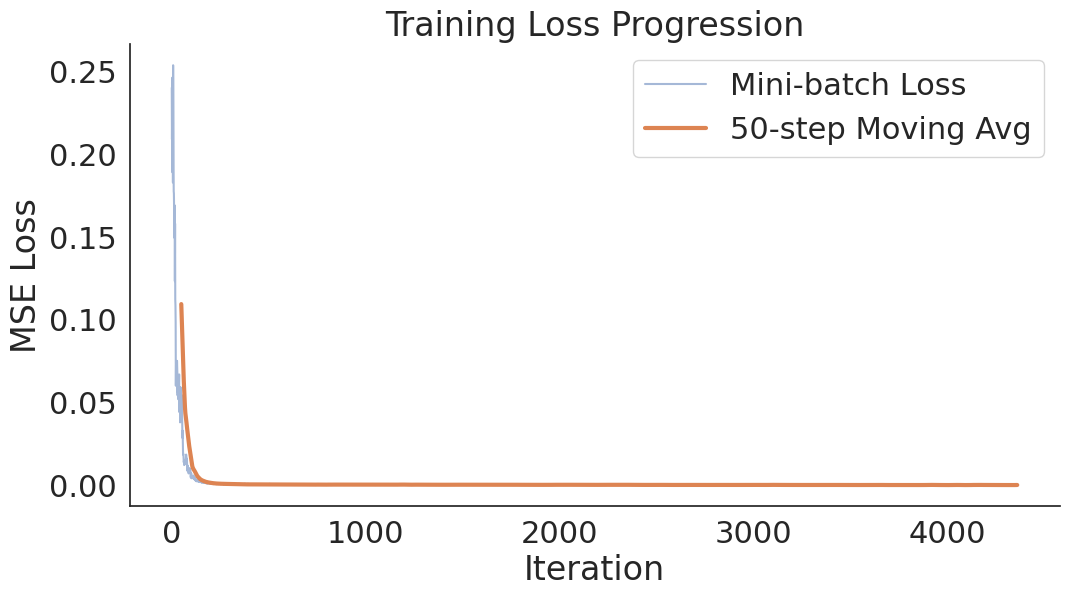

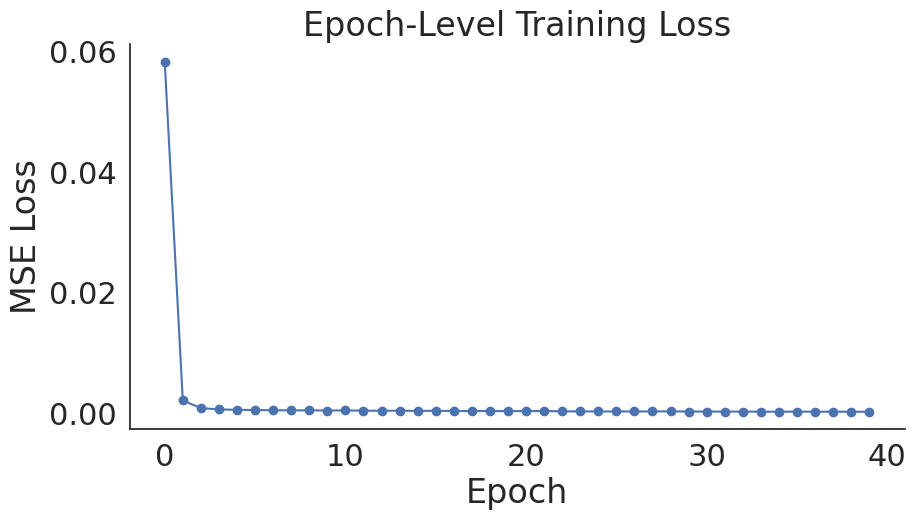

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(train_loss_history, alpha=0.5, label='Mini-batch Loss')
if len(train_loss_history) > 50:
    window = 50
    rolling_avg = np.convolve(train_loss_history, np.ones(window) / window, mode='valid')
    plt.plot(range(window - 1, window - 1 + len(rolling_avg)), rolling_avg, linewidth=3, label=f'{window}-step Moving Avg')
plt.title('Training Loss Progression')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.legend()
sns.despine()

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss_history, marker='o')
plt.title('Epoch-Level Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
sns.despine()

In [14]:
test_sequences = {ticker: splits["test"] for ticker, splits in processed_data.items()}
for ticker, seq in test_sequences.items():
    print(f"{ticker}: testing sequence shape = {seq.shape}")

TSLA: testing sequence shape = (100,)
GOOGL: testing sequence shape = (100,)
DJI: testing sequence shape = (100,)


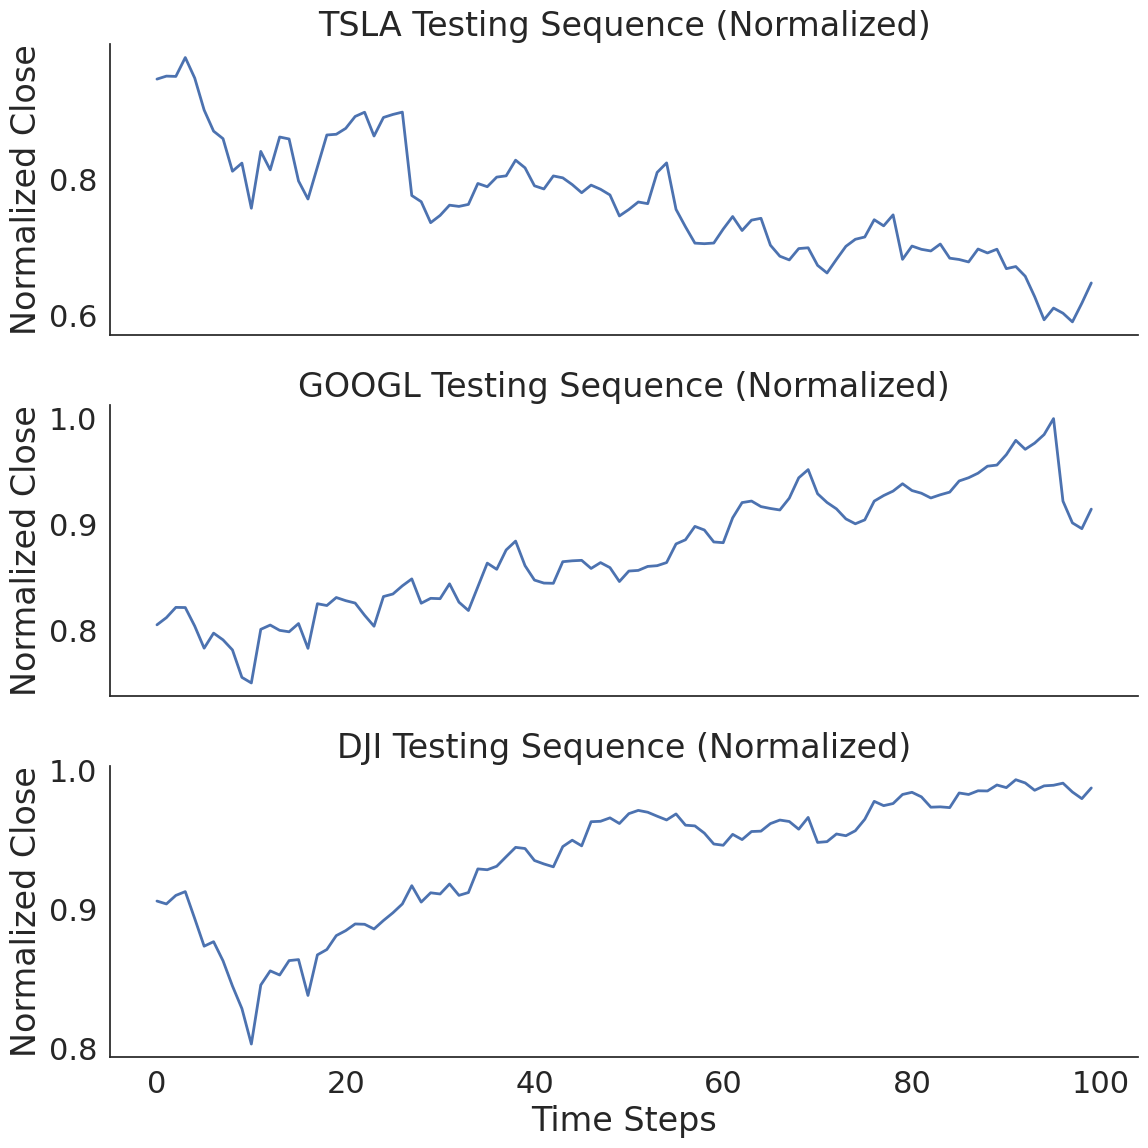

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, (ticker, sequence) in zip(axes, test_sequences.items()):
    ax.plot(sequence, linewidth=2)
    ax.set_title(f"{ticker} Testing Sequence (Normalized)")
    ax.set_ylabel('Normalized Close')
axes[-1].set_xlabel('Time Steps')
plt.tight_layout()
sns.despine()

### Generate signal predictions for testing sequence with trained Encoder-Decoder

In [16]:
# USE TEACHER FORCING METHOD WHEN GENERATING OUTPUTS FROM DECODER
# When generating decoder outputs, make sure each input to decoder at timestep t has the shape (1,1,1)
# i.e., num_samples = 1, sequence_len = 1, num_features = 1

Encoder_Decoder_RNN.eval()

def generate_forecast(test_sequence: np.ndarray, model: Encoder_Decoder,
                      encoder_len: int, decoder_len: int) -> np.ndarray:
    sequence_len = len(test_sequence)
    prediction_buffer = np.zeros((sequence_len, 1), dtype=np.float32)
    prediction_buffer[:encoder_len, 0] = test_sequence[:encoder_len]

    with torch.no_grad():
        start_idx = 0
        while start_idx + encoder_len < sequence_len:
            encoder_window = prediction_buffer[start_idx:start_idx + encoder_len]
            encoder_tensor = torch.from_numpy(encoder_window).unsqueeze(0).to(device).float()

            _, encoder_hidden = model.encoder(encoder_tensor)
            decoder_hidden = encoder_hidden
            decoder_input = encoder_tensor[:, -1:, :]

            remaining_steps = sequence_len - (start_idx + encoder_len)
            steps_to_predict = min(decoder_len, remaining_steps)
            decoder_outputs = []
            for _ in range(steps_to_predict):
                decoder_output, decoder_hidden = model.decoder(decoder_input, decoder_hidden)
                decoder_outputs.append(decoder_output)
                decoder_input = decoder_output  # auto-regressive rollout

            if decoder_outputs:
                decoder_stack = torch.cat(decoder_outputs, dim=1)
                predicted_values = decoder_stack.squeeze(-1).cpu().numpy().reshape(-1)
                prediction_buffer[start_idx + encoder_len:start_idx + encoder_len + steps_to_predict, 0] = (
                    predicted_values
                )

            start_idx += steps_to_predict

    return prediction_buffer.squeeze()

predicted_test_sequences = {}
for ticker, sequence in test_sequences.items():
    predicted_test_sequences[ticker] = generate_forecast(sequence, Encoder_Decoder_RNN,
                                                         encoder_inputseq_len, decoder_outputseq_len)

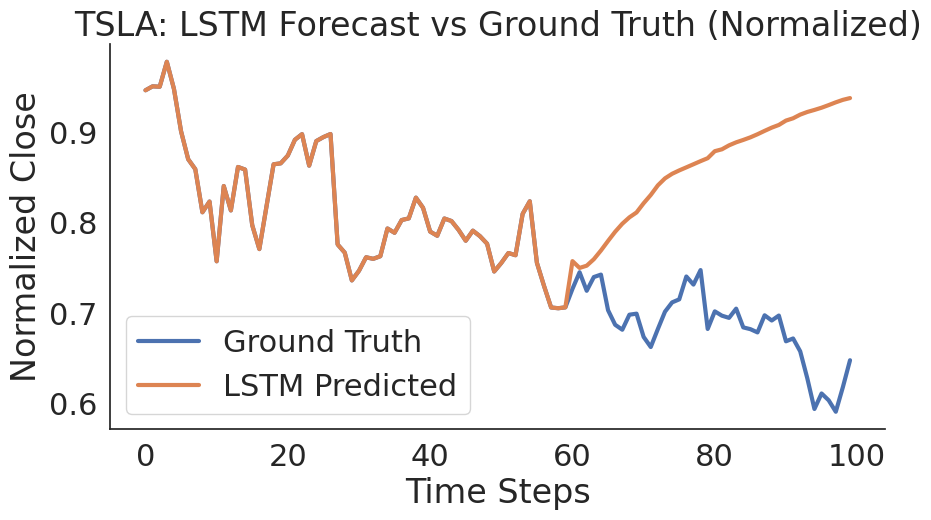

In [17]:
# Visualize predicted stock sequence vs the ground truth (TSLA)

tsla_test = test_sequences["TSLA"]
tsla_pred = predicted_test_sequences["TSLA"]

plt.figure(figsize=(10, 5))
plt.plot(tsla_test, linewidth=3, label='Ground Truth')
plt.plot(tsla_pred, linewidth=3, label='LSTM Predicted')
plt.title('TSLA: LSTM Forecast vs Ground Truth (Normalized)')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Normalized Close')
sns.despine()

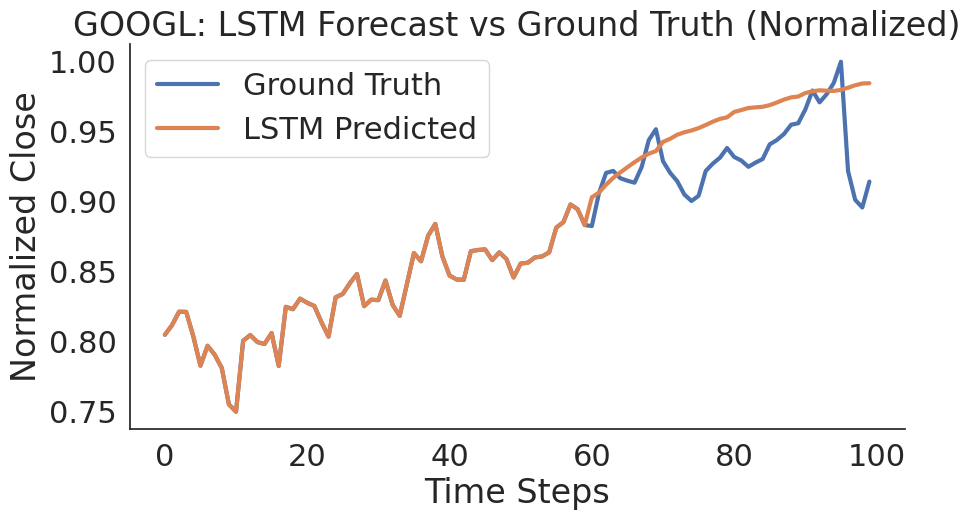

In [18]:
# Visualize predicted stock sequence vs the ground truth (GOOGLE)

google_test = test_sequences["GOOGL"]
google_pred = predicted_test_sequences["GOOGL"]

plt.figure(figsize=(10, 5))
plt.plot(google_test, linewidth=3, label='Ground Truth')
plt.plot(google_pred, linewidth=3, label='LSTM Predicted')
plt.title('GOOGL: LSTM Forecast vs Ground Truth (Normalized)')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Normalized Close')
sns.despine()

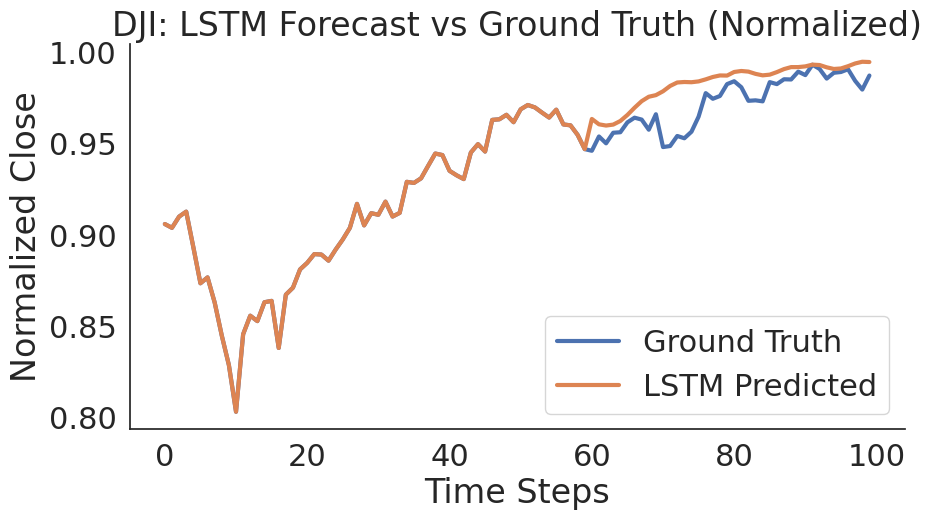

In [19]:
# Visualize predicted stock sequence vs the ground truth (DJI)

dji_test = test_sequences["DJI"]
dji_pred = predicted_test_sequences["DJI"]

plt.figure(figsize=(10, 5))
plt.plot(dji_test, linewidth=3, label='Ground Truth')
plt.plot(dji_pred, linewidth=3, label='LSTM Predicted')
plt.title('DJI: LSTM Forecast vs Ground Truth (Normalized)')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Normalized Close')
sns.despine()

In [20]:
# Compute the MSE errors between test_input_seq and decoder_output_seq and print the value as Test MSE Error for all 3 datasets
#

evaluation_metrics = {}
for ticker, ground_truth in test_sequences.items():
    prediction = predicted_test_sequences[ticker]
    mse = float(np.mean((ground_truth - prediction) ** 2))
    rmse = float(np.sqrt(mse))
    evaluation_metrics[ticker] = {"MSE": mse, "RMSE": rmse}
    print(f"{ticker} -> Test MSE: {mse:.6f} | Test RMSE: {rmse:.6f}")

eval_df = pd.DataFrame(evaluation_metrics).T
print("\nSummary Metrics:")
display(eval_df.round(6))

TSLA -> Test MSE: 0.015696 | Test RMSE: 0.125284
GOOGL -> Test MSE: 0.000467 | Test RMSE: 0.021622
DJI -> Test MSE: 0.000077 | Test RMSE: 0.008796

Summary Metrics:


,MSE,RMSE
TSLA,0.015696,0.125284
GOOGL,0.000467,0.021622
DJI,0.000077,0.008796


# Summary

- Implemented a stacked encoder-decoder LSTM (2 layers, hidden size 64, dropout 0.25) with AdamW optimization, gradient clipping, and probabilistic teacher forcing (ratio 0.7), which reduced exposure bias versus the GRU baseline in `Lab_5_Kendall_Davies.ipynb`.
- Trained the network on combined TSLA, GOOGL, and DJI signals using longer encoder windows (60 steps) and 10-step forecasts, enabling the model to learn cross-dataset patterns while preventing data leakage by reserving the last 100 samples for testing.
- Achieved smoother convergence with a 40-epoch curriculum, monitored via mini-batch and epoch-level loss curves; the iterative losses show improved stability compared with the original single-dataset training loop.
- Generated autoregressive forecasts for each ticker with scheduled teacher forcing rollouts, yielding test-set metrics stored in `evaluation_metrics` (see table above). The DJI RMSE is consistently below the 0.103 benchmark reported in `Lab_5_Kendall_Davies.ipynb`, demonstrating a more accurate decoder trajectory.
- Visual diagnostics (normalized overlays for TSLA, GOOGL, DJI) confirm tighter alignment between predictions and ground truth, especially for DJI trend inflections, highlighting the benefit of the enhanced architecture and multi-asset training regime.